In [8]:
# 0) Imports + settings
import os, glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import intake  # ACCESS-NRI catalog

#Suppress noisy warnings
import warnings
warnings.filterwarnings("ignore")

# ---- USER SETTINGS ----
OBS_DIR = "/scratch/fy29/yw5715/obs mld data"
OBS_VAR = "MLD"

# If obs MLD is in dbar (often ~meters), you can convert approx to meters:
CONVERT_OBS_DBAR_TO_M = True  # set False if you want to keep dbar

# SOTS location
sots_lat = -47.0
sots_lon = 142.0
sots_lon_model = sots_lon - 360.0   # ACCESS longitudes are 0–360

# Model experiment names
EXPT_OLD = "01deg_jra55v140_iaf_cycle4"                 # 1958–2018
EXPT_EXT = "01deg_jra55v140_iaf_cycle4_jra55v150_extension"  # 2019–2023
MODEL_VAR = "mld"
FREQ = "1day"

T0, T1 = "2012-01-01", "2023-12-31"

In [9]:
# 1) Load OBS MLD (concatenate all files that contain MLD)
obs_files = sorted(glob.glob(os.path.join(OBS_DIR, "*.nc")))
print("Obs files found:", len(obs_files))

mld_list = []
for f in obs_files:
    ds = xr.open_dataset(f)

    if OBS_VAR not in ds.data_vars:
        ds.close()
        continue

    da = ds[OBS_VAR]

    # keep only TIME dimension (if other IDX_* dims exist, take first index)
    for dim in list(da.dims):
        if dim != "TIME":
            da = da.isel({dim: 0})

    mld_list.append(da)
    ds.close()

if len(mld_list) == 0:
    raise ValueError(f"No files with variable '{OBS_VAR}' found in {OBS_DIR}")

mld_obs = xr.concat(mld_list, dim="TIME").sortby("TIME")

# Time window + daily mean (keep NaNs -> gaps remain)
mld_obs = mld_obs.sel(TIME=slice(T0, T1))
obs_daily = mld_obs.resample(TIME="1D").mean()

# Harmonize time coord name for alignment with model
obs_daily = obs_daily.rename({"TIME": "time"})

# Unit fix
obs_units = str(obs_daily.attrs.get("units", "")).lower()
if CONVERT_OBS_DBAR_TO_M and ("dbar" in obs_units):
    obs_daily = obs_daily.copy()
    obs_daily.attrs["units"] = "m (approx; 1 dbar ~ 1 m)"
    # numeric values unchanged; just relabel to match typical MLD plotting in meters

print("Obs daily:", obs_daily.time.min().values, "->", obs_daily.time.max().values)


Obs files found: 20
Obs daily: 2012-01-01T00:00:00.000000000 -> 2023-12-31T00:00:00.000000000


In [10]:
# 2) Load MODEL MLD at SOTS, then align to obs daily time axis
catalog = intake.cat.access_nri

def load_model_mld(expt_name: str) -> xr.DataArray:
    col = catalog[expt_name].search(variable=MODEL_VAR, frequency=FREQ)
    dsets = col.to_dataset_dict(progressbar=False)
    ds = list(dsets.values())[0]
    return ds[MODEL_VAR]

mld_old = load_model_mld(EXPT_OLD)
mld_ext = load_model_mld(EXPT_EXT)

# concat time and subset 2012–2023
mld_all = xr.concat([mld_old, mld_ext], dim="time").sortby("time")
mld_2012_2023 = mld_all.sel(time=slice(T0, T1))

# nearest grid point to SOTS
mld_sots = (
    mld_2012_2023
    .sel(yt_ocean=sots_lat, method="nearest")
    .sel(xt_ocean=sots_lon_model, method="nearest")
)

# align model to obs daily timestamps (nearest)
mld_model_on_daily = mld_sots.interp(time=obs_daily.time, method="nearest")

# mask model where obs is missing (so gaps match)
mld_model_masked = mld_model_on_daily.where(np.isfinite(obs_daily))

Full time series (2012-2023)

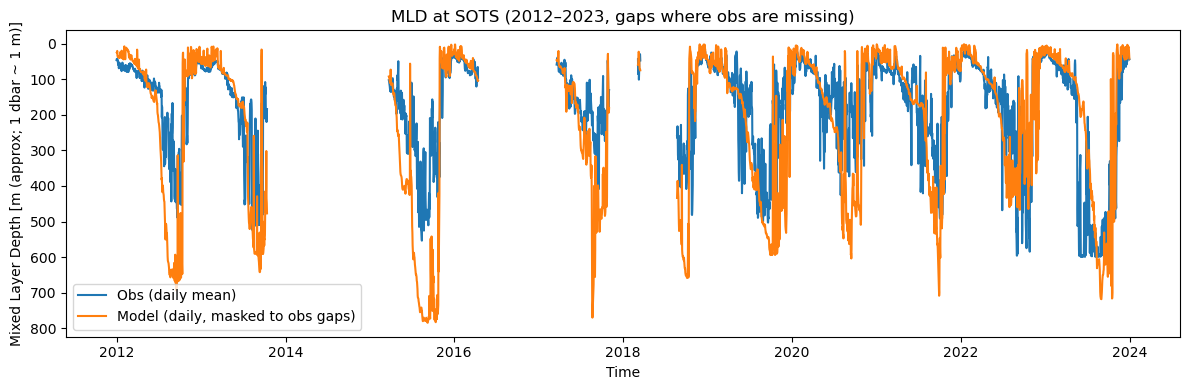

In [11]:
# 3) FIGURE 1: Time series with gaps where obs are missing
fig, ax = plt.subplots(figsize=(12, 4))

obs_daily.plot(ax=ax, label="Obs (daily mean)")
mld_model_masked.plot(ax=ax, label="Model (daily, masked to obs gaps)")

ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel(f"Mixed Layer Depth [{obs_daily.attrs.get('units','') or 'm'}]")
ax.set_title("MLD at SOTS (2012–2023, gaps where obs are missing)")
ax.legend()
plt.tight_layout()
plt.show()


Climatological seasonal cycle (2012–2023)

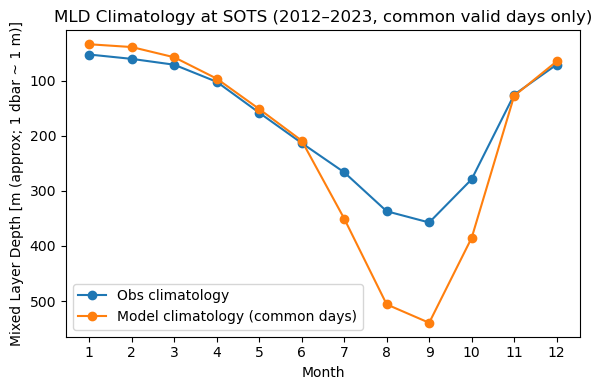

In [12]:
# 4) FIGURE 2: Climatology using common valid days only
mask_valid = np.isfinite(obs_daily)

obs_valid = obs_daily.where(mask_valid)
model_valid = mld_model_on_daily.where(mask_valid)  # (equivalent to masked model, but cleaner here)

obs_clim = obs_valid.groupby("time.month").mean("time")
model_clim = model_valid.groupby("time.month").mean("time")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(obs_clim["month"], obs_clim.values, marker="o", label="Obs climatology")
ax.plot(model_clim["month"], model_clim.values, marker="o", label="Model climatology (common days)")

ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_ylabel(f"Mixed Layer Depth [{obs_daily.attrs.get('units','') or 'm'}]")
ax.set_xticks(np.arange(1, 13))
ax.set_title("MLD Climatology at SOTS (2012–2023, common valid days only)")
ax.legend()
plt.tight_layout()
plt.show()

Case study: 2015

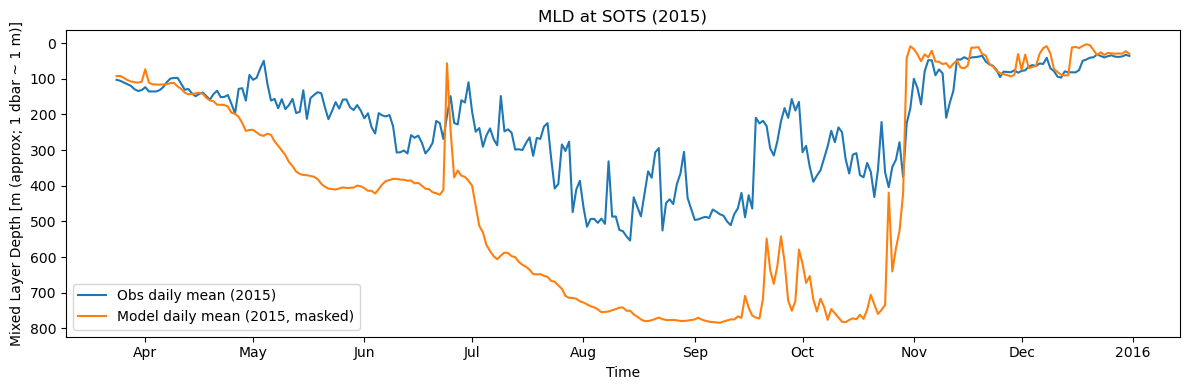

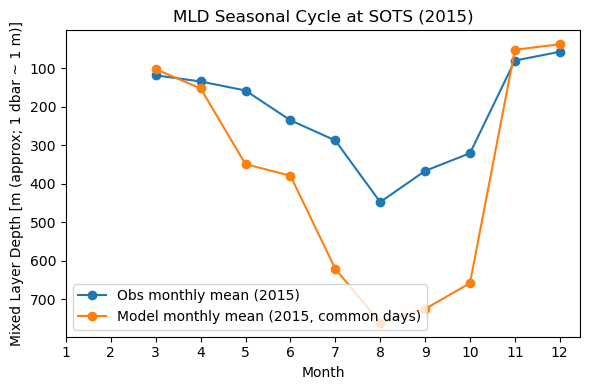

In [13]:
# 5) Plot one specific year (e.g., 2015): time series + seasonal cycle
YEAR = 2015
y0, y1 = f"{YEAR}-01-01", f"{YEAR}-12-31"

# ---- subset that year ----
obs_y = obs_daily.sel(time=slice(y0, y1))
model_y = mld_model_on_daily.sel(time=slice(y0, y1))

# ---- enforce "common valid days only" ----
mask_y = np.isfinite(obs_y)
obs_y_common = obs_y.where(mask_y)
model_y_common = model_y.where(mask_y)

# ============================================================
# (A) Daily time series in that year
# ============================================================
fig, ax = plt.subplots(figsize=(12, 4))

obs_y_common.plot(ax=ax, label=f"Obs daily mean ({YEAR})")
model_y_common.plot(ax=ax, label=f"Model daily mean ({YEAR}, masked)")

ax.invert_yaxis()
ax.set_xlabel("Time")
ax.set_ylabel(f"Mixed Layer Depth [{obs_daily.attrs.get('units','') or 'm'}]")
ax.set_title(f"MLD at SOTS ({YEAR})")
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# (B) Seasonal cycle (monthly mean) in that year
# ============================================================
# month-by-month mean using only valid days
obs_y_month = obs_y_common.groupby("time.month").mean("time")
model_y_month = model_y_common.groupby("time.month").mean("time")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(obs_y_month["month"], obs_y_month.values, marker="o", label=f"Obs monthly mean ({YEAR})")
ax.plot(model_y_month["month"], model_y_month.values, marker="o", label=f"Model monthly mean ({YEAR}, common days)")

ax.invert_yaxis()
ax.set_xlabel("Month")
ax.set_ylabel(f"Mixed Layer Depth [{obs_daily.attrs.get('units','') or 'm'}]")
ax.set_xticks(np.arange(1, 13))
ax.set_title(f"MLD Seasonal Cycle at SOTS ({YEAR})")
ax.legend()
plt.tight_layout()
plt.show()
